# ВШЭ 2026: Математические методы анализа данных

## Семинар: метод ближайших соседей и решающие деревья

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, mean_squared_error

# Метод $k$ ближайших соседей (KNN)

KNN — непараметрический алгоритм обучения с учителем. Во время `fit` он фактически запоминает обучающую выборку. Для нового объекта алгоритм:

1. вычисляет расстояния до обучающих объектов;
2. выбирает $k$ ближайших соседей;
3. агрегирует их ответы.

Часто используется евклидово расстояние:

$$
\rho(x, z) = \sqrt{\sum_{j=1}^{d}(x_j-z_j)^2}.
$$

Поскольку расстояние зависит от масштаба признаков, числовые признаки перед KNN обычно стандартизируют. Ниже `StandardScaler` и модель объединены в `Pipeline`: средние и стандартные отклонения оцениваются только по обучающим данным.

## KNN для классификации

В классификации новый объект получает самый частый класс среди $k$ соседей:

$$
\hat y(x) = \operatorname{mode}\{y_{(1)}, \ldots, y_{(k)}\}.
$$

При `weights='distance'` более близкие соседи получают больший вес. Малое $k$ создаёт сложную границу и повышает риск переобучения; большое $k$ сглаживает границу и может привести к недообучению. Подбирать $k$ по тестовой выборке нельзя, поэтому выделим отдельную валидационную часть.

In [ ]:
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_knn_cls, y_knn_cls = make_moons(n_samples=600, noise=0.25, random_state=42)

# 60% — обучение, 20% — валидация, 20% — финальный тест
X_knn_trainval, X_knn_test, y_knn_trainval, y_knn_test = train_test_split(
    X_knn_cls, y_knn_cls, test_size=0.2, random_state=42, stratify=y_knn_cls
)
X_knn_train, X_knn_valid, y_knn_train, y_knn_valid = train_test_split(
    X_knn_trainval, y_knn_trainval, test_size=0.25, random_state=42,
    stratify=y_knn_trainval
)

k_values = range(1, 31)
valid_accuracy = []
for k in k_values:
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_knn_train, y_knn_train)
    valid_accuracy.append(model.score(X_knn_valid, y_knn_valid))

best_k_cls = list(k_values)[int(np.argmax(valid_accuracy))]
knn_classifier = make_pipeline(
    StandardScaler(), KNeighborsClassifier(n_neighbors=best_k_cls)
)
knn_classifier.fit(X_knn_trainval, y_knn_trainval)
knn_test_pred = knn_classifier.predict(X_knn_test)

print('Лучшее k по валидации:', best_k_cls)
print('Accuracy на тесте:', round(accuracy_score(y_knn_test, knn_test_pred), 3))

Лучшее k по валидации: 6
Accuracy на тесте: 0.925


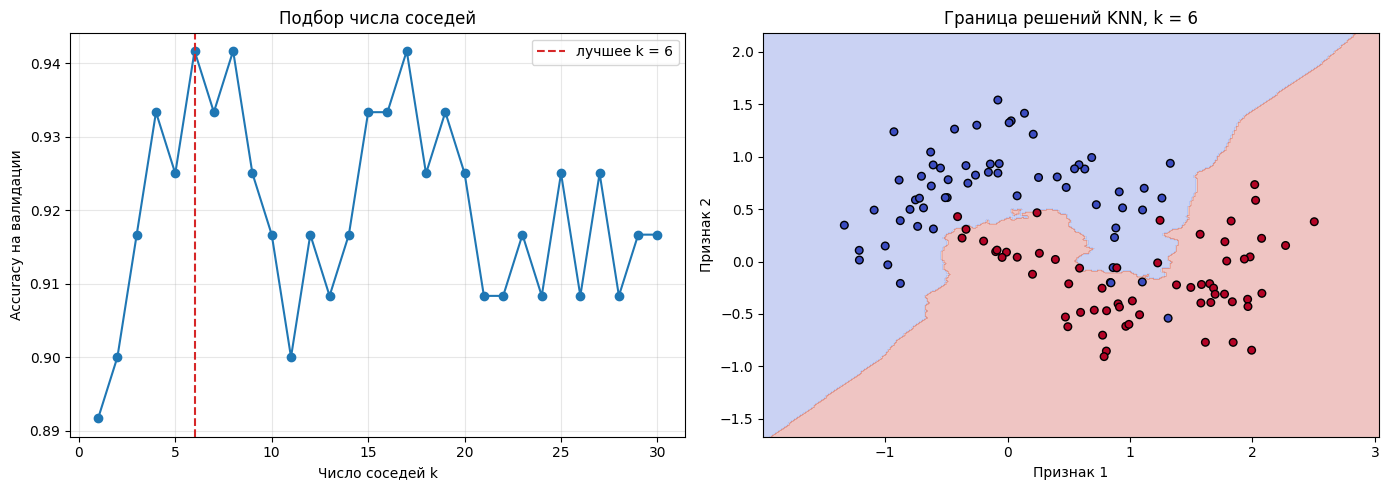

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_values), valid_accuracy, marker='o')
axes[0].axvline(best_k_cls, color='tab:red', linestyle='--', label=f'лучшее k = {best_k_cls}')
axes[0].set(xlabel='Число соседей k', ylabel='Accuracy на валидации',
            title='Подбор числа соседей')
axes[0].legend()
axes[0].grid(alpha=0.3)

x_min, x_max = X_knn_cls[:, 0].min() - 0.5, X_knn_cls[:, 0].max() + 0.5
y_min, y_max = X_knn_cls[:, 1].min() - 0.5, X_knn_cls[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
zz = knn_classifier.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, zz, alpha=0.3, cmap='coolwarm')
axes[1].scatter(X_knn_test[:, 0], X_knn_test[:, 1], c=y_knn_test,
                cmap='coolwarm', edgecolor='k', s=30)
axes[1].set(title=f'Граница решений KNN, k = {best_k_cls}', xlabel='Признак 1', ylabel='Признак 2')

plt.tight_layout()
plt.show()

## KNN для регрессии

В регрессии прогноз равен среднему ответов соседей:

$$
\hat y(x) = \frac{1}{k}\sum_{i=1}^{k}y_{(i)}.
$$

При взвешивании по расстоянию используется взвешенное среднее. Как и в классификации, увеличение $k$ делает прогноз более гладким, но может скрыть локальную структуру данных.

In [ ]:
rng = np.random.default_rng(42)
X_knn_reg = np.sort(rng.uniform(0, 10, size=300)).reshape(-1, 1)
y_knn_reg = np.sin(X_knn_reg[:, 0]) + 0.25 * rng.normal(size=len(X_knn_reg))

X_reg_trainval, X_reg_test, y_reg_trainval, y_reg_test = train_test_split(
    X_knn_reg, y_knn_reg, test_size=0.2, random_state=42
)
X_reg_train, X_reg_valid, y_reg_train, y_reg_valid = train_test_split(
    X_reg_trainval, y_reg_trainval, test_size=0.25, random_state=42
)

reg_valid_rmse = []
for k in k_values:
    model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))
    model.fit(X_reg_train, y_reg_train)
    pred_valid = model.predict(X_reg_valid)
    reg_valid_rmse.append(np.sqrt(mean_squared_error(y_reg_valid, pred_valid)))

best_k_reg = list(k_values)[int(np.argmin(reg_valid_rmse))]
knn_regressor = make_pipeline(
    StandardScaler(), KNeighborsRegressor(n_neighbors=best_k_reg)
)
knn_regressor.fit(X_reg_trainval, y_reg_trainval)
pred_test = knn_regressor.predict(X_reg_test)

print('Лучшее k по валидации:', best_k_reg)
print('RMSE на тесте:', round(np.sqrt(mean_squared_error(y_reg_test, pred_test)), 3))

Лучшее k по валидации: 9
RMSE на тесте: 0.307


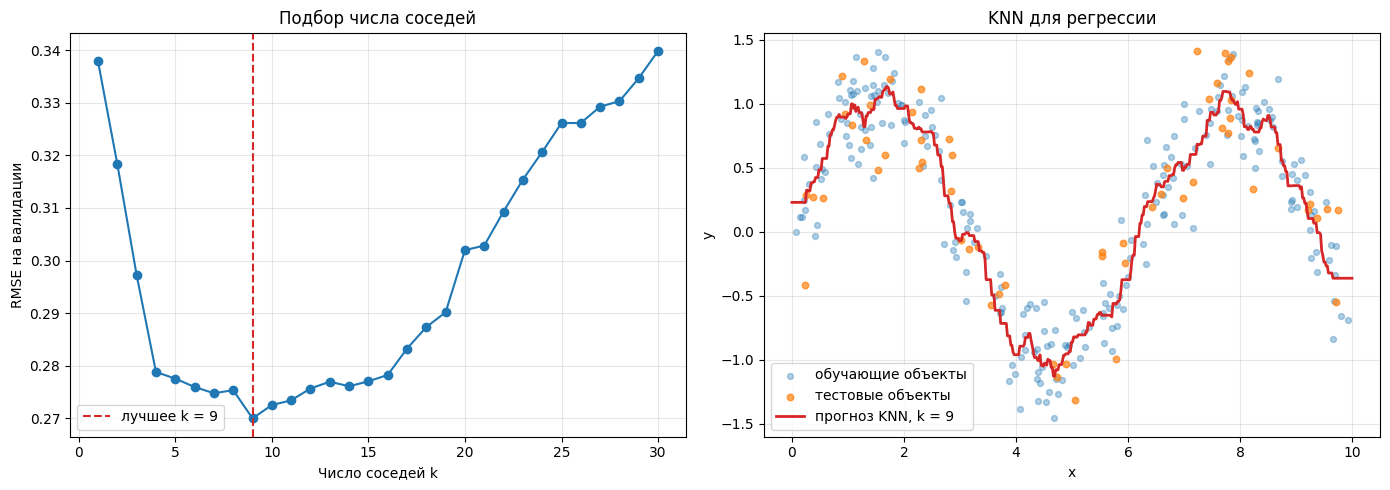

In [ ]:
x_grid = np.linspace(0, 10, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_values), reg_valid_rmse, marker='o')
axes[0].axvline(best_k_reg, color='tab:red', linestyle='--', label=f'лучшее k = {best_k_reg}')
axes[0].set(xlabel='Число соседей k', ylabel='RMSE на валидации',
            title='Подбор числа соседей')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(X_reg_trainval[:, 0], y_reg_trainval, alpha=0.35, s=18,
                label='обучающие объекты')
axes[1].scatter(X_reg_test[:, 0], y_reg_test, alpha=0.7, s=22,
                label='тестовые объекты')
axes[1].plot(x_grid[:, 0], knn_regressor.predict(x_grid), color='tab:red', linewidth=2,
             label=f'прогноз KNN, k = {best_k_reg}')
axes[1].set(xlabel='x', ylabel='y', title='KNN для регрессии')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Практические свойства KNN

* **Плюсы:** простая идея, почти нет этапа обучения, нелинейная граница решений получается естественным образом.
* **Минусы:** предсказание замедляется при росте обучающей выборки; нужно хранить данные; результат чувствителен к масштабу, шуму и выбору метрики.
* В пространствах высокой размерности расстояния становятся менее информативными — проявляется **проклятие размерности**.
* Значения $k$, метрику расстояния и схему весов следует подбирать по валидации или кросс-валидации.

# Загрузка выборки

Загрузим набор данных [Titanic](https://gist.github.com/michhar/2dfd2de0d4f8727f873422c5d959fff5).

    ОПИСАНИЕ ПЕРЕМЕННЫХ:
    Survived        выжил ли пассажир
                    (0 = нет; 1 = да)
    Pclass          класс пассажира
                    (1 = первый; 2 = второй; 3 = третий)
    Name            имя
    Sex             пол
    Age             возраст
    SibSp           число братьев, сестёр и супругов на борту
    Parch           число родителей и детей на борту
    Ticket          номер билета
    Fare            стоимость билета
    Cabin           каюта
    Embarked        порт посадки
                    (C = Шербур; Q = Куинстаун; S = Саутгемптон)

    ДОПОЛНИТЕЛЬНЫЕ ЗАМЕЧАНИЯ:
    Pclass служит приближённым показателем социально-экономического статуса:
    1-й класс — высокий, 2-й — средний, 3-й — низкий.

    Возраст указан в годах. Для детей младше года он может быть дробным.
    Если возраст оценён приблизительно, значение имеет вид xx.5.

Файл `titanic.csv` сохранён рядом с тетрадкой, поэтому повторный запуск не требует доступа к сети.

In [ ]:
from pathlib import Path

data_path = Path('titanic.csv')
if not data_path.exists():
    raise FileNotFoundError('Положите файл titanic.csv в одну папку с тетрадкой')

data = pd.read_csv(data_path)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
def data_preprocessing(data_input):
    """Подготавливает данные Titanic к обучению моделей."""

    # Удаляем идентификаторы и текстовые признаки, которые не используем в семинаре
    cols_2_drop = ['PassengerId', 'Ticket', 'Cabin', 'Name']
    data_input = data_input.drop(cols_2_drop, axis=1).copy()

    # Заполняем пропуски возраста специальным значением
    data_input['Age'] = data_input['Age'].fillna(-999)

    # Кодируем пол числами
    data_input['Sex'] = data_input['Sex'].replace({'male': 0, 'female': 1}).astype(int)

    # Удаляем строки с оставшимися пропусками
    data_input = data_input.dropna()

    # Кодируем порт посадки с помощью one-hot encoding
    data_input = pd.get_dummies(data_input, columns=['Embarked'], prefix_sep='=', dtype=int)

    return data_input

In [ ]:
data_preproc = data_preprocessing(data)

C:\Users\Danie\AppData\Local\Temp\ipykernel_40480\1056229677.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_input['Sex'] = data_input['Sex'].replace({'male': 0, 'female': 1}).astype(int)


In [ ]:
data_preproc.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked=C,Embarked=Q,Embarked=S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


# Разведочный анализ данных (EDA)

In [ ]:
# Задаём столбец с целевой переменной
y_column = 'Survived'

# Выбираем столбцы с признаками
X_columns = data_preproc.columns[data_preproc.columns != y_column]

X_columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked=C',
       'Embarked=Q', 'Embarked=S'],
      dtype='object')

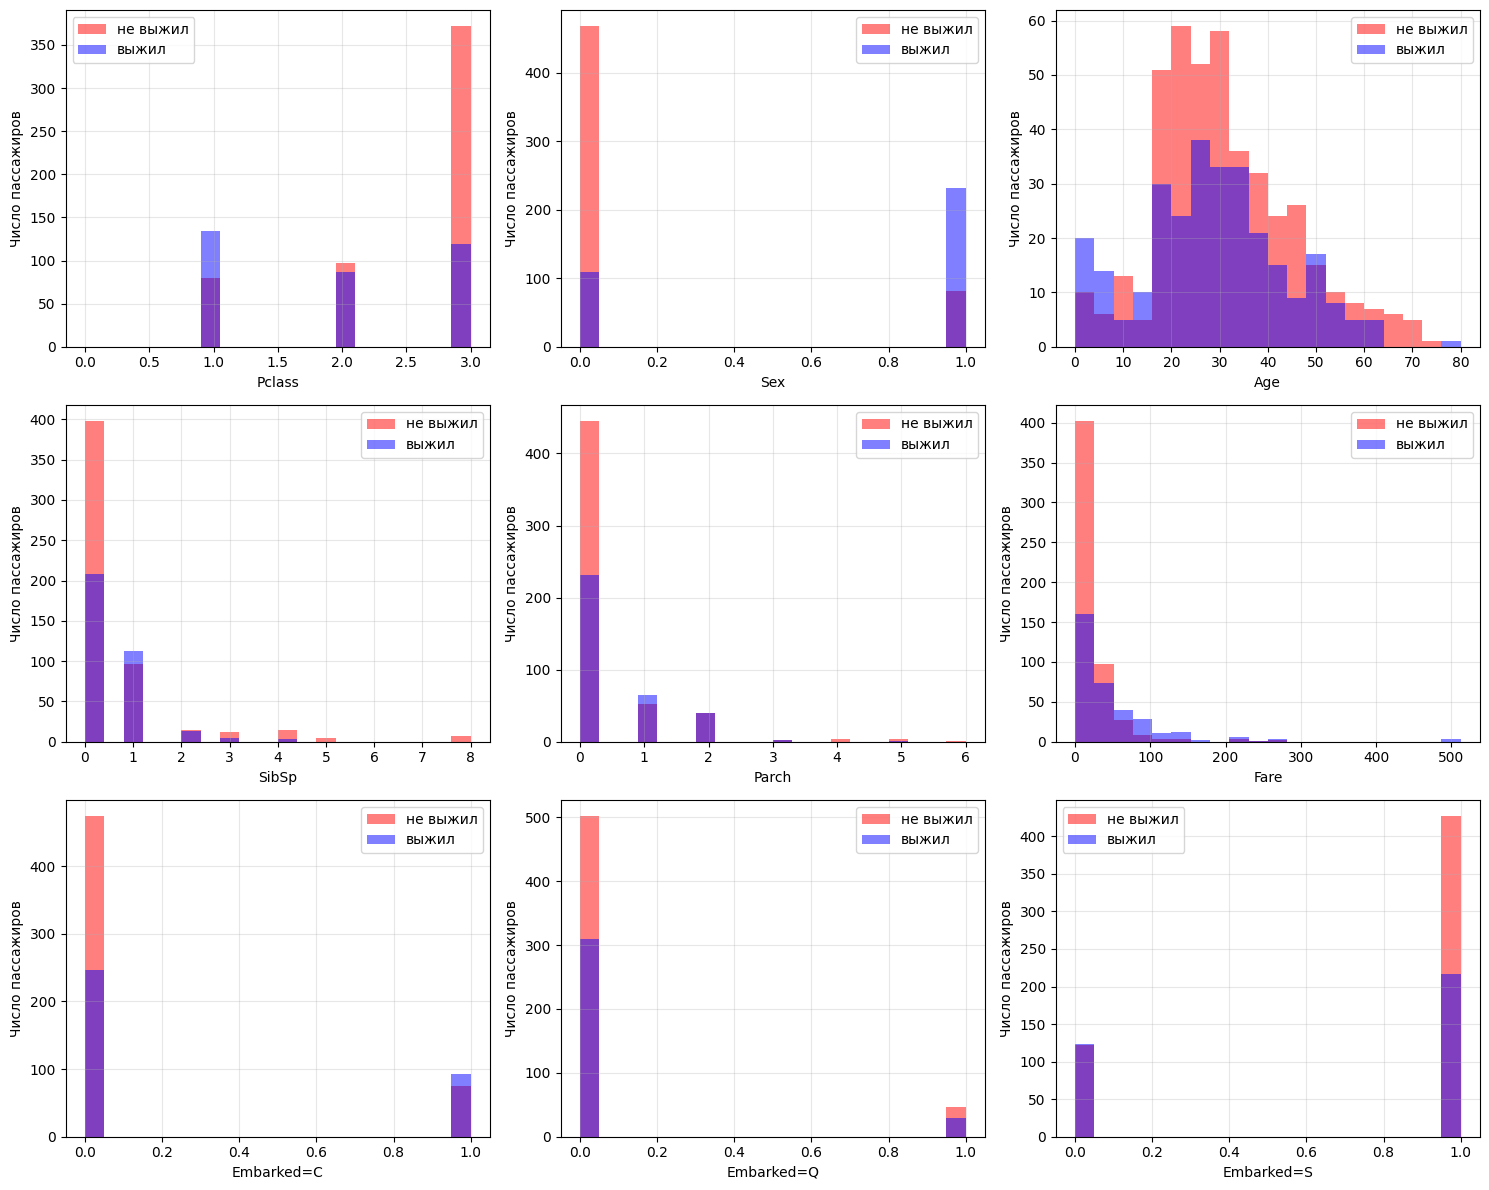

In [ ]:
# Задаём размер рисунка
plt.figure(figsize=(15, 12))

# Для каждого признака строим отдельный график
for i_col in range(len(X_columns)):
    plt.subplot(3, 3, i_col + 1)

    # Получаем значения признака и целевой переменной
    x_col = data_preproc[X_columns[i_col]].values
    y_col = data_preproc[y_column].values

    # Строим гистограммы отдельно для двух классов
    bins = np.linspace(0, x_col.max(), 21)
    plt.grid(alpha=0.3)
    plt.hist(x_col[y_col == 0], bins=bins, color='r', alpha=0.5, label='не выжил')
    plt.hist(x_col[y_col == 1], bins=bins, color='b', alpha=0.5, label='выжил')

    plt.xlabel(X_columns[i_col])
    plt.ylabel('Число пассажиров')
    plt.legend(loc='best')

plt.tight_layout()
plt.show()

## Разбиение данных на обучающую и тестовую выборки

In [ ]:
from sklearn.model_selection import train_test_split

X = data_preproc[X_columns].values
y = data_preproc[y_column].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,       # 30% объектов отправляем в тест
    random_state=123,    # фиксируем перемешивание для воспроизводимости
    stratify=y,
)

# Решающее дерево

**Решающее дерево** — непараметрический алгоритм обучения с учителем, который применяют и для классификации, и для регрессии.

**Основная идея:** последовательно делить выборку на всё более однородные подмножества. Последовательность условий образует дерево решений.

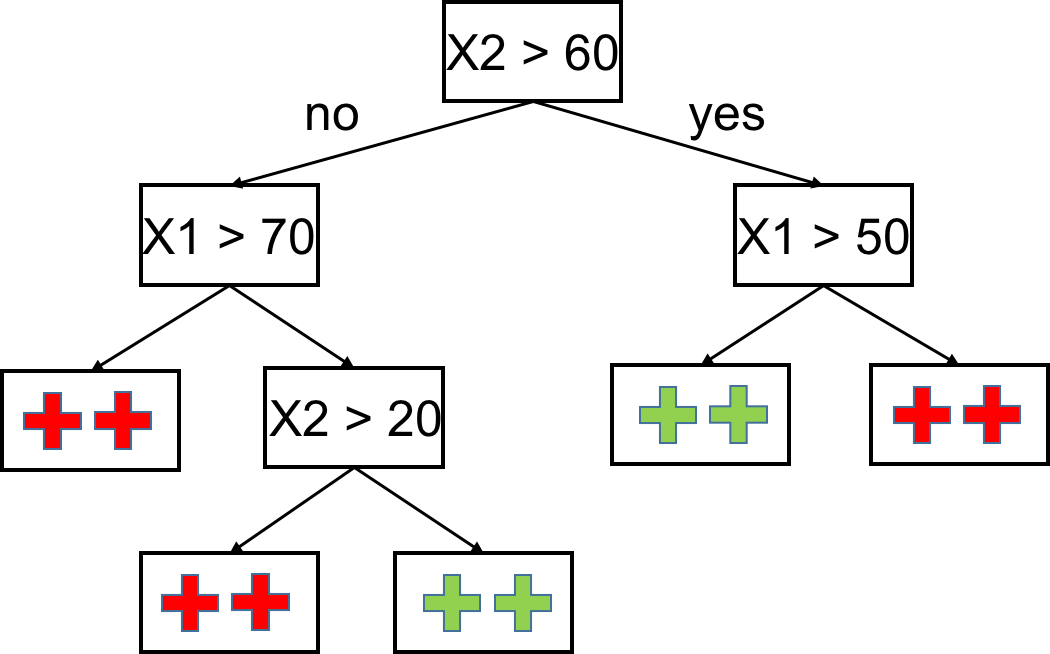

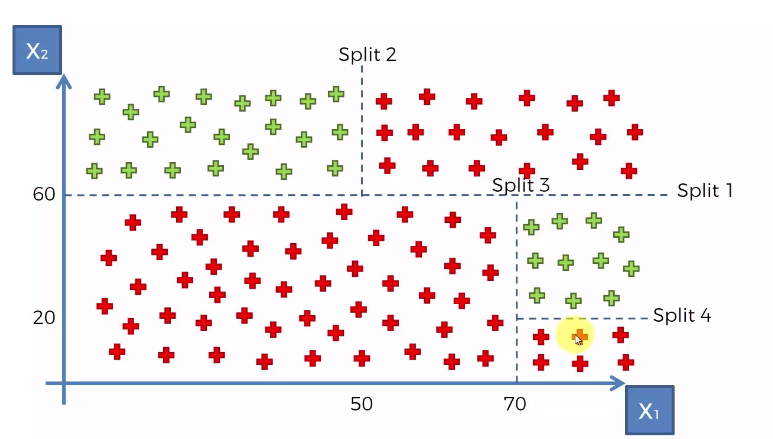

*Пунктирные линии показывают последовательные разбиения пространства признаков (Split = разбиение).*

# Решающее дерево для классификации

Построение дерева начинается с корневой вершины. Для каждой вершины выбирается такое условие, которое максимизирует **прирост информации**:

$$
\Delta I_{node} = I_{node} - \left(I_{left}\frac{N_{left}}{N_{node}} + I_{right}\frac{N_{right}}{N_{node}}\right),
$$

где $I_{node}$ — **impurity** узла, то есть степень его «нечистоты».

## Popular impurity criteria

**Gini impurity**

Gini impurity оценивает вероятность ошибочной классификации случайного объекта, если назначать класс в соответствии с распределением классов в узле. Если все объекты относятся к одному классу, узел чистый и impurity равна 0. Чем равномернее распределены классы, тем выше impurity; максимум для $C$ классов равен $1 - 1/C$.

$$
I_{node} = G(node) = \sum_{i=1}^{C}p_i(1-p_i) = 1 - \sum_{i=1}^{C}p_i^2.
$$

**Энтропия**

Энтропия измеряет неопределённость распределения классов. При разбиении мы стремимся уменьшить энтропию, то есть получить прирост информации.

$$
I_{node} = E(node) = -\sum_{i=1}^{C}p_i\log(p_i).
$$

**Ошибка классификации**

$$
I_{node} = 1 - \max_i p_i,
$$

где $p_i$ — доля объектов класса $i$ в вершине:

$$
p_i = \frac{N_i}{\sum_{i=1}^{C}N_i}.
$$

Рассмотрим пример:




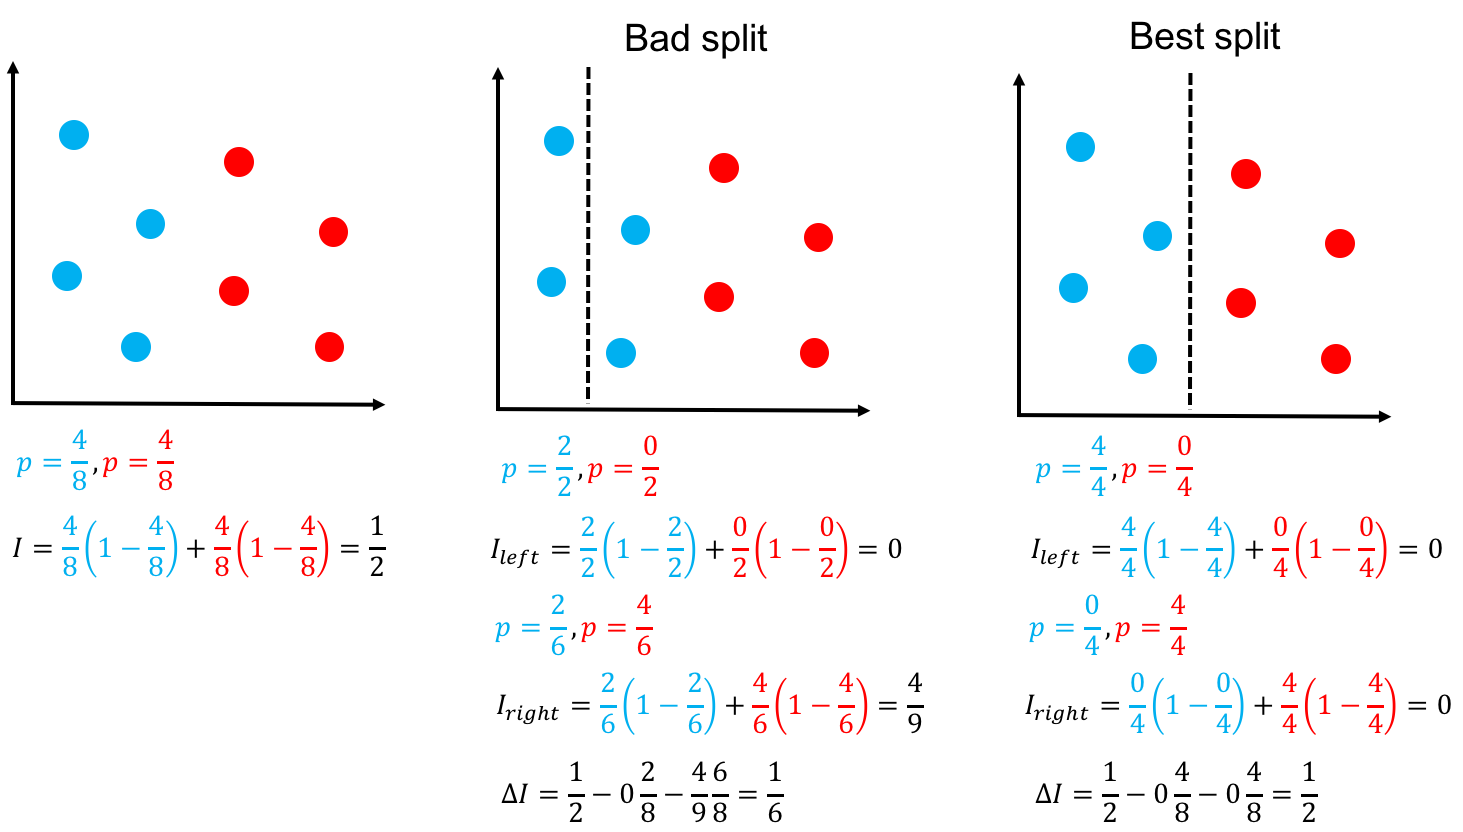

[Подробное объяснение](https://blog.quantinsti.com/gini-index/#Information-Gain) impurity criteria.

**Этап предсказания**

Новый объект проходит от корня по условиям дерева до листа. В задаче классификации ему назначается самый частый класс среди обучающих объектов этого листа.

## Реализация классификатора с нуля

Реализуем решающее дерево для классификации.

Код объёмный, но каждый его шаг соответствует описанному выше алгоритму.

In [ ]:
class Node(object):

    def __init__(self):
        """Вершина решающего дерева."""

        self.right = None
        self.left = None

        self.threshold = None
        self.column = None

        self.depth = None
        self.probas = None

        self.is_terminal = False

In [ ]:
class DecisionTreeClassifier_from_scratch(object):

    def __init__(self, max_depth=3, min_samples_leaf=1, min_samples_split=2, impurity='gini'):
        """
        Классификатор на основе решающего дерева.

        Параметры
        ---------
        max_depth : int
            Максимальная глубина дерева.
        min_samples_leaf : int
            Минимальное число объектов в листе.
        min_samples_split : int
            Минимальное число объектов в вершине для выполнения разбиения.
        impurity : str
            Impurity criterion, используемый при построении дерева.
        """

        # Сохраняем гиперпараметры внутри объекта
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.impurity = impurity

        # Объект дерева
        self.Tree = None

        # Вспомогательные объекты
        self.classes = []

    def get_params(self, deep=True):
        """
        Возвращает параметры класса.

        Параметры
        ---------
        deep : boolean
            Если True, возвращает параметры этого оценивателя и вложенных оценивателей.

        Возвращает
        ----------
        params : dict
            Параметры класса.
        """

        params = {'max_depth': self.max_depth,
                  'min_samples_leaf': self.min_samples_leaf,
                  'min_samples_split': self.min_samples_split,
                  'impurity': self.impurity}

        return params


    def set_params(self, **params):
        """
        Устанавливает параметры класса.

        Параметры
        ---------
        params : dict
            Словарь параметров класса.
        """

        for key, value in params.items():
            setattr(self, key, value)

        return self



    def node_probabilities(self, y):
        """
        Оценивает вероятности классов в данных.

        Параметры
        ---------
        y : numpy.array, shape = (n_objects)
            Одномерный массив меток объектов.
            В классификации метки — целые числа из {0, 1, 2, ...}.

        Возвращает
        ----------
        probas : numpy.array, shape = (n_objects, n_classes)
            Двумерный массив предсказанных вероятностей классов.
            Пример:
                y_predicted_proba = [[0.1, 0.9],
                                     [0.8, 0.2],
                                     [0.0, 1.0],
                                     ...]
        """

        # Список для вероятностей классов
        probas = []

        # Для каждого класса в данных
        for one_class in self.classes:

            # Оцениваем вероятность класса
            class_proba = 1. * (y == one_class).sum() / len(y)
            # class_proba = 0.8 (пример)

            # Сохраняем вероятность
            probas.append(class_proba)

        return probas


    def gini_calculation(self, probas):
        """
        Вычисляет Gini impurity.

        Параметры
        ---------
        probas : numpy.array, shape = (n_objects, n_classes)
            Двумерный массив предсказанных вероятностей классов.
            Пример:
                probas = [0.1, 0.9]

        Возвращает
        ----------
        gini : float
            Значение Gini impurity.
        """

        gini = 1
        for p in probas:
            gini -= p**2

        return gini


    def impurity_calculation(self, y):
        """
        Вычисляет impurity данных.

        Параметры
        ---------
        y : numpy.array, shape = (n_objects)
            Одномерный массив меток объектов.
            В классификации метки — целые числа из {0, 1, 2, ...}.

        Возвращает
        ----------
        impurity : float
            Impurity данных.
        """

        # Оцениваем вероятность каждого класса
        probas = self.node_probabilities(y)
        # probas = [0.90, 0.10] (пример)

        # Вычисляем impurity данных
        if self.impurity == 'gini':
            impurity = self.gini_calculation(probas)
            # impurity = 0.6 (пример)

        return impurity


    def best_split(self, X, y):
        """
        Находит лучшее разбиение данных в вершине дерева.

        Параметры
        ---------
        X : numpy.array, shape = (n_objects, n_features)
            Матрица объектов, описанных входными признаками.
        y : numpy.array, shape = (n_objects)
            Одномерный массив меток объектов.
            В классификации метки — целые числа из {0, 1, 2, ...}.

        Возвращает
        ----------
        best_split_column : int
            Индекс признака для лучшего разбиения.
        best_threshold : float
            Порог лучшего разбиения.
        X_left : numpy.array, shape = (n_objects, n_features)
            Матрица объектов в левом потомке.
        y_left : numpy.array, shape = (n_objects)
            Метки объектов в левом потомке.
            В классификации метки — целые числа из {0, 1, 2, ...}.
        X_right : numpy.array, shape = (n_objects, n_features)
            Матрица объектов в правом потомке.
        y_right : numpy.array, shape = (n_objects)
            Метки объектов в правом потомке.
            В классификации метки — целые числа из {0, 1, 2, ...}.
        """

        # Параметры лучшего разбиения
        best_split_column = None
        best_threshold = None
        best_information_gain = -999

        # Impurity до разбиения
        impurity = self.impurity_calculation(y)
        # impurity = 0.8 (пример)

        # Перебираем признаки
        for split_column in range(X.shape[1]):

            # Выбираем значения признака
            x_col = X[:, split_column]
            # x_col = [2.6, 1.3, 0.5, ...] (пример)

            # Перебираем возможные пороги
            for i_x in range(0, len(x_col)):

                # Берём значение как порог
                threshold = x_col[i_x]
                # threshold = 1.3 (пример)

                # Делим объекты на левого и правого потомков
                y_right = y[x_col > threshold]
                y_left = y[x_col <= threshold]
                # y_left = [0, 1, 1, 0, 1] (пример)

                if len(y_right) == 0 or len(y_left) == 0:
                    continue

                # Вычисляем impurity дочерних узлов
                impurity_left = self.impurity_calculation(y_left)
                impurity_right = self.impurity_calculation(y_right)
                # impurity_right = 0.6 (пример)

                # Вычисляем прирост информации
                information_gain = impurity
                information_gain -= impurity_left * len(y_left) / len(y)
                information_gain -= impurity_right * len(y_right) / len(y)
                # information_gain = 0.2 (пример)

                # Проверяем, стало ли разбиение лучшим
                if information_gain > best_information_gain:
                    best_split_column = split_column
                    best_threshold = threshold
                    best_information_gain = information_gain

        # Если допустимого разбиения нет
        if best_information_gain == -999:
            return None, None, None, None, None, None

        # Выполняем лучшее найденное разбиение
        x_col = X[:, best_split_column]
        X_left = X[x_col <= best_threshold, :]
        y_left = y[x_col <= best_threshold]
        X_right = X[x_col > best_threshold, :]
        y_right = y[x_col > best_threshold]

        return best_split_column, best_threshold, X_left, y_left, X_right, y_right



    def decision_tree(self, node, X, y):
        """
        Рекурсивно строит решающее дерево.

        Параметры
        ---------
        node : Node() object
            Текущая вершина дерева.
        X : numpy.array, shape = (n_objects, n_features)
            Матрица объектов, описанных входными признаками.
        y : numpy.array, shape = (n_objects)
            Одномерный массив меток объектов.
            В классификации метки — целые числа из {0, 1, 2, ...}.
        """

        # Проверяем условия остановки
        if node.depth >= self.max_depth:      # проверка max_depth
            node.is_terminal = True
            return
        if len(X) < self.min_samples_split:   # проверка min_samples_split
            node.is_terminal = True
            return
        if len(np.unique(y)) == 1:
            node.is_terminal = True
            return

        # Ищем лучшее разбиение
        split_column, threshold, X_left, y_left, X_right, y_right = self.best_split(X, y) # выполняем разбиение
        # split_column = 2 (пример): индекс признака
        # threshold = 2.74 (пример): условие split_column > threshold

        # Проверяем дополнительные условия остановки
        if split_column is None:
            node.is_terminal = True
            return
        if len(X_left) < self.min_samples_leaf or len(X_right) < self.min_samples_leaf:  # проверка min_samples_leaf
            node.is_terminal = True
            return


        # Сохраняем параметры разбиения в вершине
        node.column = split_column
        node.threshold = threshold

        # Создаём левого потомка
        node.left = Node()
        node.left.depth = node.depth + 1
        node.left.probas = self.node_probabilities(y_left)

        # Создаём правого потомка
        node.right = Node()
        node.right.depth = node.depth + 1
        node.right.probas = self.node_probabilities(y_right)

        # Рекурсивно обрабатываем дочерние вершины
        self.decision_tree(node.right, X_right, y_right)
        self.decision_tree(node.left, X_left, y_left)


    def fit(self, X, y):
        """
        Обучает классификатор на основе решающего дерева.

        Параметры
        ---------
        X : numpy.array, shape = (n_objects, n_features)
            Матрица объектов, описанных входными признаками.
        y : numpy.array, shape = (n_objects)
            Одномерный массив меток объектов.
            В классификации метки — целые числа из {0, 1, 2, ...}.
        """

        # Получаем уникальные метки классов
        self.classes = np.unique(y)
        # self.classes = [0, 1] (пример)

        # Создаём корневую вершину
        self.Tree = Node()                             # пустая вершина
        self.Tree.depth = 1                            # глубина вершины
        self.Tree.probas = self.node_probabilities(y)  # начальные вероятности классов

        # Строим дерево
        self.decision_tree(self.Tree, X, y)


    def one_prediction(self, node, x):
        """
        Получает вероятности классов для одного объекта.

        Параметры
        ---------
        node : Node() object
            Текущая вершина дерева.
        x : numpy.array, shape = (n_features,)
            Массив признаков одного объекта.
        """

        # Условие остановки
        if node.is_terminal == True:     # если это лист
            return node.probas                           # возвращаем вероятности в листе
            # node.probas = [0.9, 0.1] (пример)

        # Переходим к одному из потомков
        # Если условие выполнено, идём вправо
        if x[node.column] > node.threshold:
            # Правый потомок
            probas = self.one_prediction(node.right, x)
            # probas = [0.9, 0.1] (пример)
        else:
            # Левый потомок
            probas = self.one_prediction(node.left, x)
            # probas = [0.9, 0.1] (пример)

        return probas


    def predict_proba(self, X):
        """
        Предсказывает вероятности классов для новых объектов.

        Параметры
        ---------
        X : numpy.array, shape = (n_objects, n_features)
            Матрица объектов, описанных входными признаками.

        Возвращает
        ----------
        y_predicted_proba : numpy.array, shape = (n_objects, n_classes)
            Двумерный массив предсказанных вероятностей классов.
            Пример:
                y_predicted_proba = [[0.1, 0.9],
                                     [0.8, 0.2],
                                     [0.0, 1.0],
                                     ...]
        """

        # Список для предсказанных вероятностей
        y_predicted_proba = []

        # Получаем прогноз для каждого объекта
        for one_x in X:

            # Прогноз для одного объекта
            one_proba = self.one_prediction(self.Tree, one_x)
            # one_proba = [0.9, 0.1] (пример)

            # Сохраняем прогноз
            y_predicted_proba.append(one_proba)

        return np.array(y_predicted_proba)


    def predict(self, X):
        """
        Предсказывает метки классов для новых объектов.

        Параметры
        ---------
        X : numpy.array, shape = (n_objects, n_features)
            Матрица объектов, описанных входными признаками.

        Возвращает
        ----------
        y_predicted : numpy.array, shape = (n_objects)
            Одномерный массив предсказанных меток.
            В классификации метки — целые числа из {0, 1, 2, ...}.
        """

        # Предсказываем вероятности
        y_predicted_proba = self.predict_proba(X)
        # y_predicted_proba = [[0.90, 0.10],
        #                      [0.23, 0.77],
        #                       ...]  (пример)

        # Выбираем класс с наибольшей вероятностью
        y_predicted = y_predicted_proba.argmax(axis=1)
        # y_predicted = [0, 1] (пример)

        return y_predicted

In [ ]:
%time
clf = DecisionTreeClassifier_from_scratch(max_depth=10, min_samples_leaf=1, min_samples_split=2, impurity='gini')
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

CPU times: total: 0 ns
Wall time: 0 ns


In [ ]:
pred[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0], dtype=int64)

In [ ]:
y_test[:10]

array([1, 0, 0, 0, 0, 1, 0, 0, 1, 0], dtype=int64)

In [ ]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       165
           1       0.80      0.71      0.75       102

    accuracy                           0.82       267
   macro avg       0.82      0.80      0.80       267
weighted avg       0.82      0.82      0.82       267



**Задание:** модифицируйте классификатор и реализуйте критерий энтропии.

In [ ]:
# ВАШ КОД ЗДЕСЬ

## Реализация в sklearn

Теперь рассмотрим готовую реализацию из sklearn.

    class sklearn.tree.DecisionTreeClassifier(*, criterion='gini',
    splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1,
    min_weight_fraction_leaf=0.0, max_features=None, random_state=None,
    max_leaf_nodes=None, min_impurity_decrease=0.0,
    class_weight=None, ccp_alpha=0.0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=10, min_samples_leaf=1, min_samples_split=2, criterion='gini')
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       165
           1       0.72      0.74      0.73       102

    accuracy                           0.79       267
   macro avg       0.78      0.78      0.78       267
weighted avg       0.79      0.79      0.79       267



Результаты близки, что ожидаемо: выше мы реализовали упрощённую версию `DecisionTreeClassifier` из sklearn.

## Визуализация решающего дерева

In [ ]:
from sklearn.tree import plot_tree as sklearn_plot_tree


def show_tree(model, cols):
    """Рисует дерево средствами sklearn без внешней зависимости Graphviz."""
    sklearn_plot_tree(
        model,
        filled=True,
        rounded=True,
        feature_names=list(cols),
        class_names=['не выжил', 'выжил'],
        proportion=True,
        fontsize=8,
    )

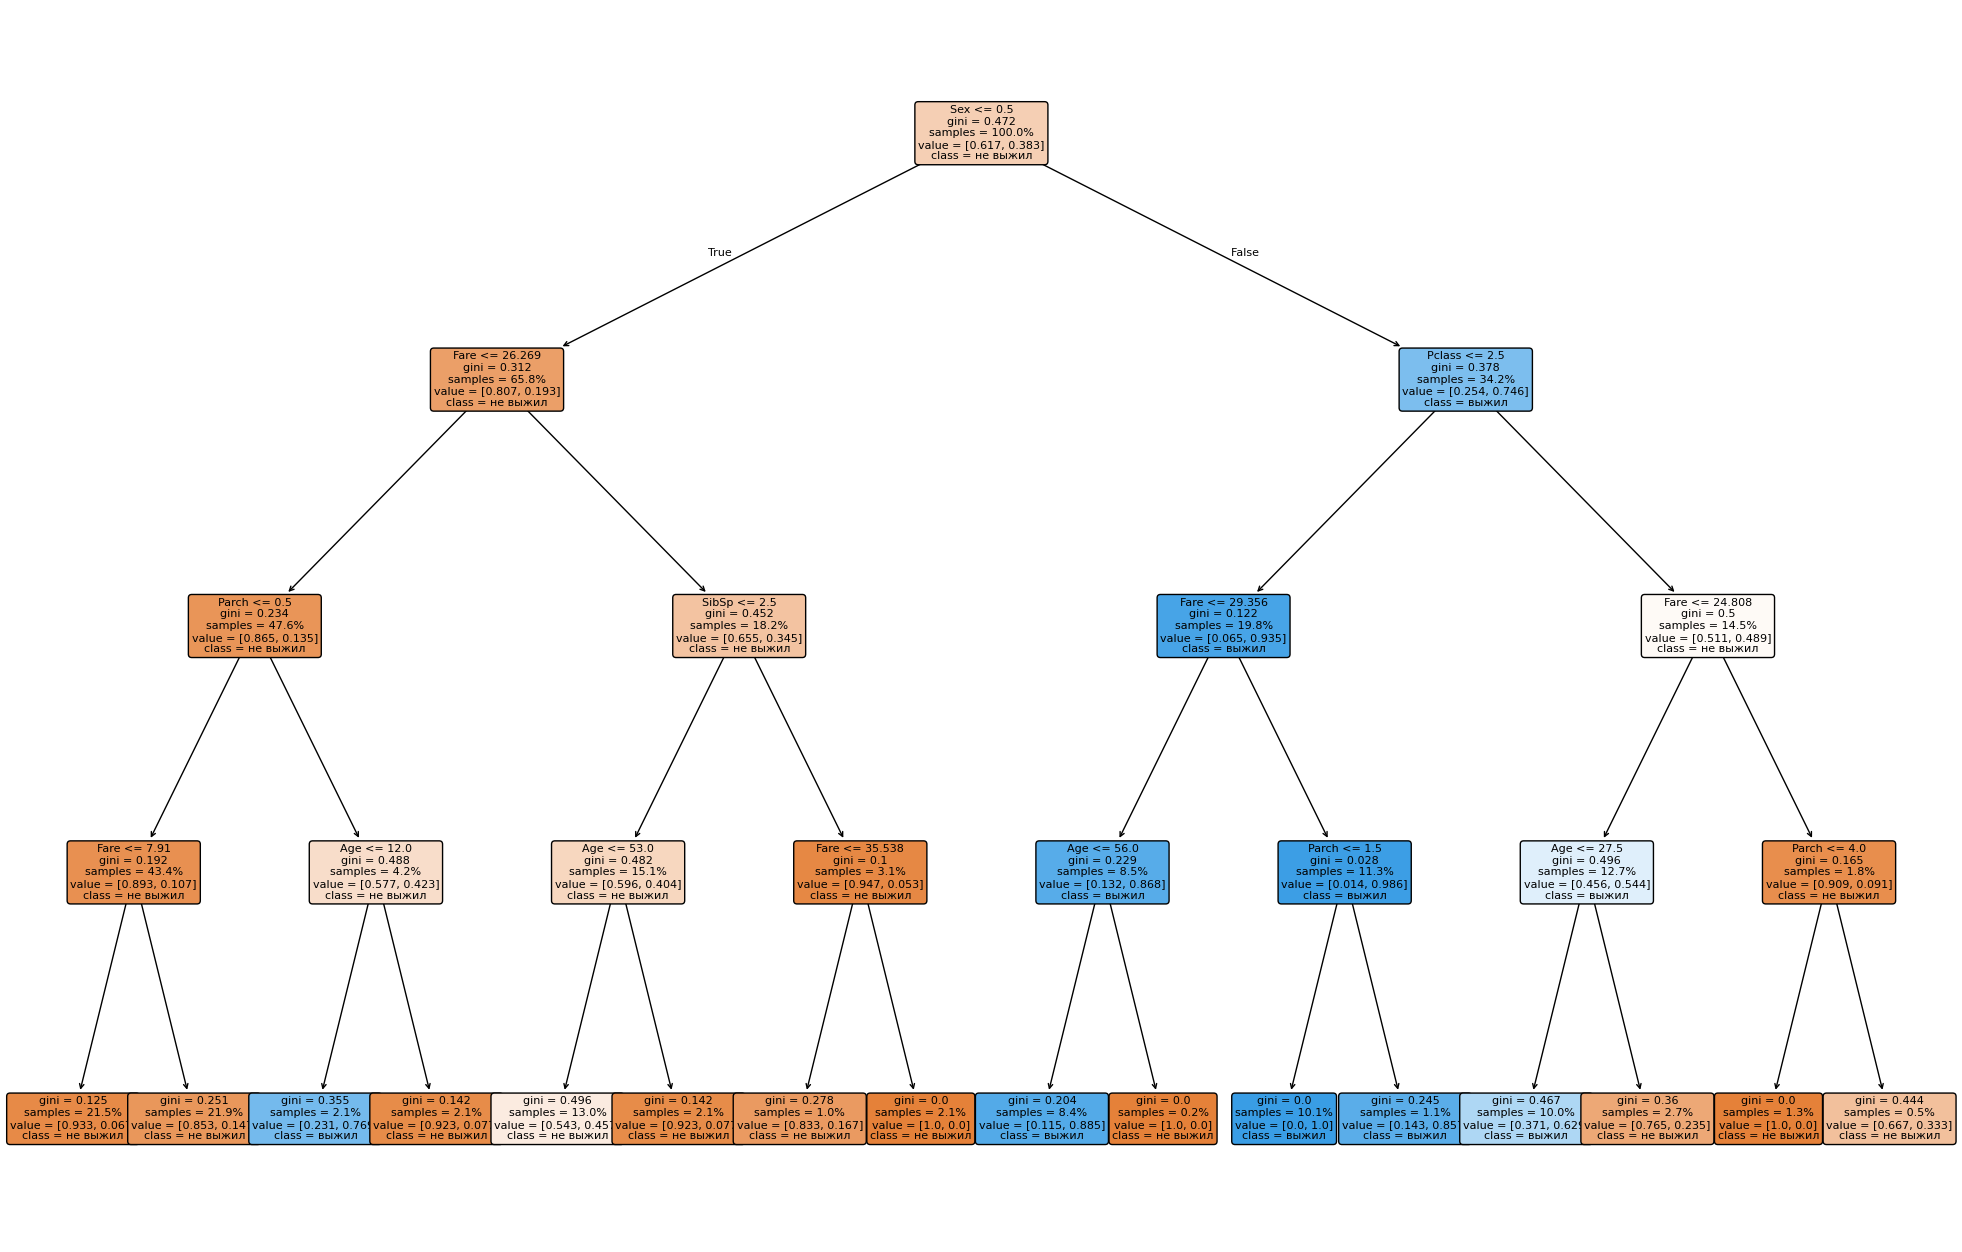

In [ ]:
clf = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
clf.fit(X_train, y_train)
plt.figure(figsize=(25, 16))
plt.axis('off')
show_tree(clf, X_columns)
plt.show()

## В чём слабое место решающих деревьев?

Решающие деревья обладают **высокой дисперсией**: небольшие изменения обучающей выборки могут привести к заметно отличающимся деревьям.

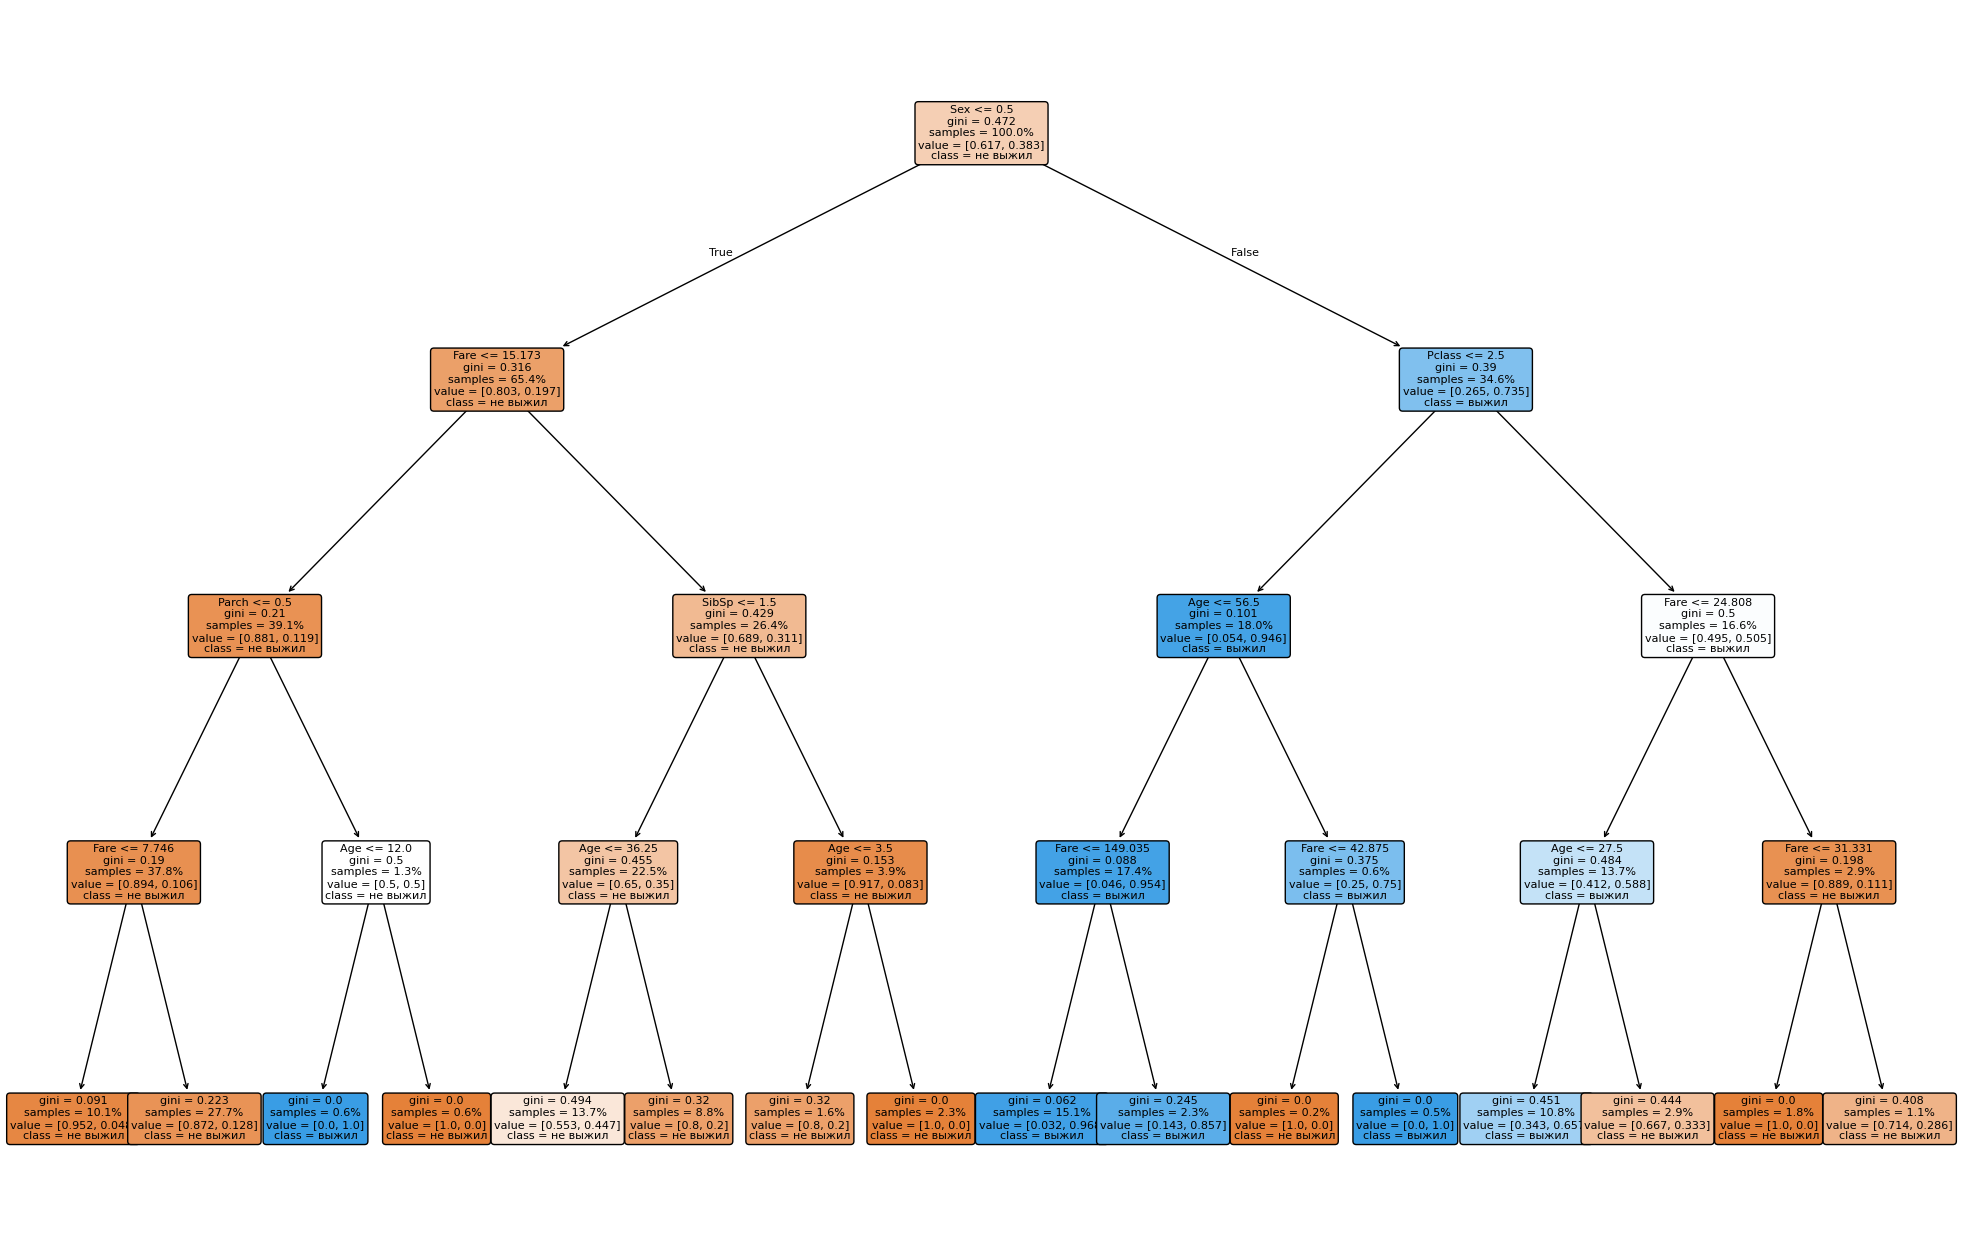

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       165
           1       0.82      0.69      0.75       102

    accuracy                           0.82       267
   macro avg       0.82      0.80      0.81       267
weighted avg       0.82      0.82      0.82       267



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% объектов отправляем в тест
    random_state=5,     # изменяем случайное разбиение
    stratify=y,
)

clf1 = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
clf1.fit(X_train, y_train)
plt.figure(figsize=(25, 16))
plt.axis('off')
show_tree(clf1, X_columns)
plt.show()

pred = clf1.predict(X_test)
print(classification_report(y_test, pred))

Мы изменили только `random_state` при вызове `train_test_split`, но структура дерева заметно поменялась. Немного изменилось и качество классификации.

# Подбор гиперпараметров

Найдём подходящие гиперпараметры классификатора с помощью поиска по сетке.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Классификатор с параметрами по умолчанию
clf = DecisionTreeClassifier(random_state=42)

# Сетка значений гиперпараметров
parameters = {
    'max_depth': [1, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 50],
}

gs = GridSearchCV(
    clf,                 # модель, параметры которой подбираем
    parameters,          # сетка гиперпараметров
    scoring='accuracy',  # оптимизируемая метрика классификации
    cv=3,                # число блоков кросс-валидации
)

gs.fit(X_train, y_train)
gs.best_params_

{'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [ ]:
pred = gs.predict(X_test)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86       165
           1       0.79      0.72      0.75       102

    accuracy                           0.82       267
   macro avg       0.81      0.80      0.81       267
weighted avg       0.82      0.82      0.82       267



Качество улучшилось.

## Влияние параметров

**Что означают эти параметры и как они влияют на итоговое дерево?**

Рассмотрим искусственную задачу бинарной классификации: точки образуют две вложенные окружности.

Чтобы усложнить задачу, добавим шум, случайно изменив некоторые метки классов.

In [ ]:
from sklearn.datasets import make_circles
import random

random.seed(1)
N = 1000

X, y = make_circles(n_samples=N, noise=0.1, factor=0.6, random_state=1)

# Добавляем шум: случайно меняем некоторые метки классов
for i, yy in enumerate(y):
    if random.randint(0, 30) % 30 == 0:
        y[i] = (y[i] + 1) % 2

# Делим данные поровну между обучением и тестом
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=123, stratify=y
)

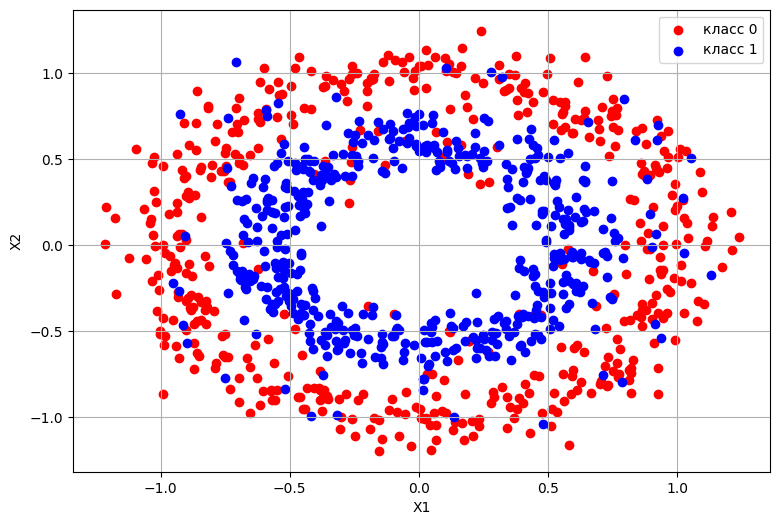

In [ ]:
plt.figure(figsize=(9, 6))

# Объекты класса 0
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='r', label='класс 0')

# Объекты класса 1
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='b', label='класс 1')

plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(loc='best')
plt.grid()
plt.show()

Получилась выборка из двух вложенных окружностей с небольшим шумом.

**Базовая модель**

Сначала построим дерево с параметрами по умолчанию.

In [ ]:
%time
clf = DecisionTreeClassifier(criterion='gini')
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print(classification_report(y_test, pred))

CPU times: total: 0 ns
Wall time: 0 ns
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       250
           1       0.86      0.83      0.85       250

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500



In [ ]:
def plot_decision_boundaries():
    """Рисует тестовые объекты и области решений текущего классификатора clf."""
    plt.figure(figsize=(9, 6))

    plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
                color='r', label='класс 0')
    plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
                color='b', label='класс 1')

    # Создаём плотную сетку и получаем класс для каждой её точки
    h = 0.01
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.5, levels=1)

    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend(loc='best')
    plt.grid()
    plt.colorbar()
    plt.show()

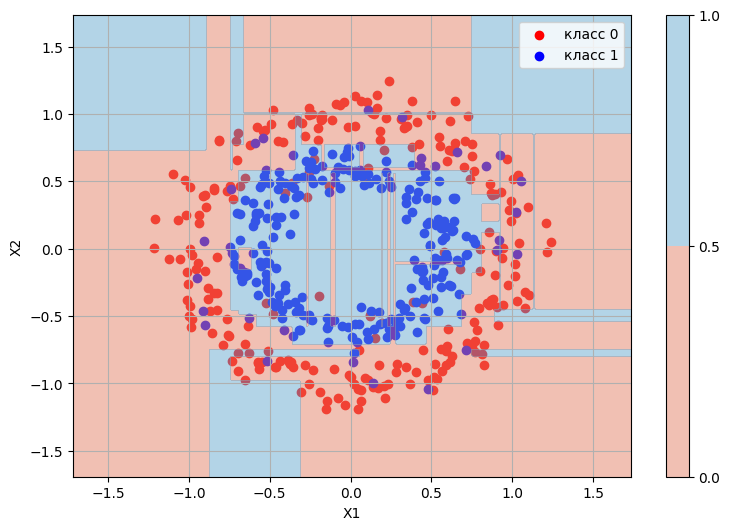

In [ ]:
plot_decision_boundaries()

Результат неплохой, но по границе решений видно, что дерево подстроилось под шум.

**Максимальная глубина (`max_depth`)**

CPU times: total: 0 ns
Wall time: 0 ns
Максимальная глубина: 1
              precision    recall  f1-score   support

           0       0.90      0.18      0.29       250
           1       0.54      0.98      0.70       250

    accuracy                           0.58       500
   macro avg       0.72      0.58      0.50       500
weighted avg       0.72      0.58      0.50       500



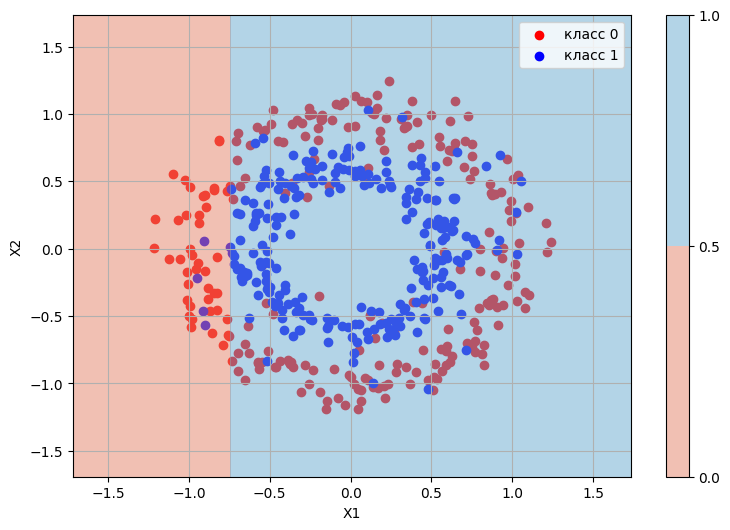

Максимальная глубина: 2
              precision    recall  f1-score   support

           0       0.91      0.45      0.60       250
           1       0.63      0.96      0.76       250

    accuracy                           0.70       500
   macro avg       0.77      0.70      0.68       500
weighted avg       0.77      0.70      0.68       500



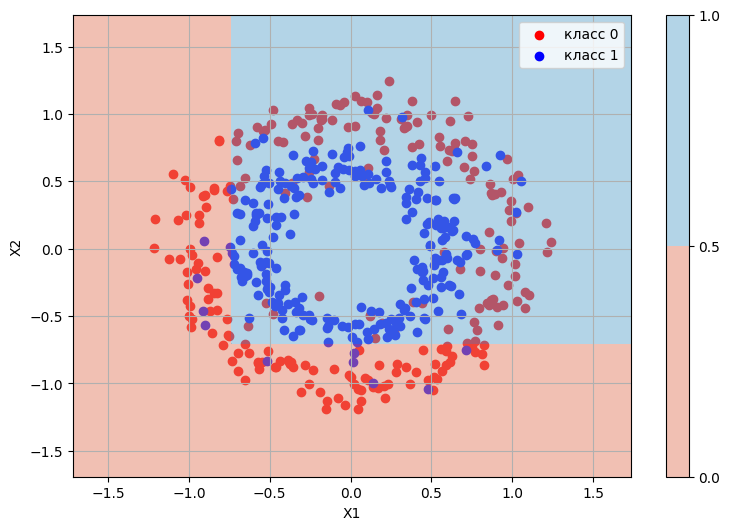

Максимальная глубина: 4
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       250
           1       0.89      0.81      0.85       250

    accuracy                           0.85       500
   macro avg       0.86      0.85      0.85       500
weighted avg       0.86      0.85      0.85       500



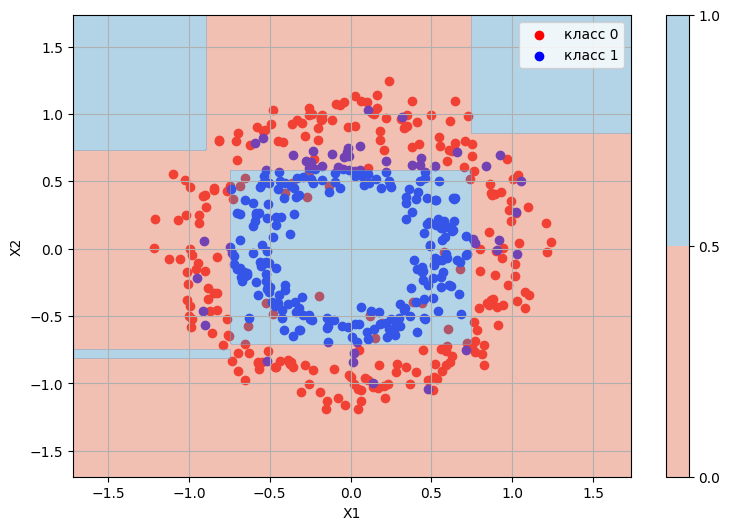

Максимальная глубина: 7
              precision    recall  f1-score   support

           0       0.86      0.87      0.87       250
           1       0.87      0.86      0.86       250

    accuracy                           0.86       500
   macro avg       0.86      0.86      0.86       500
weighted avg       0.86      0.86      0.86       500



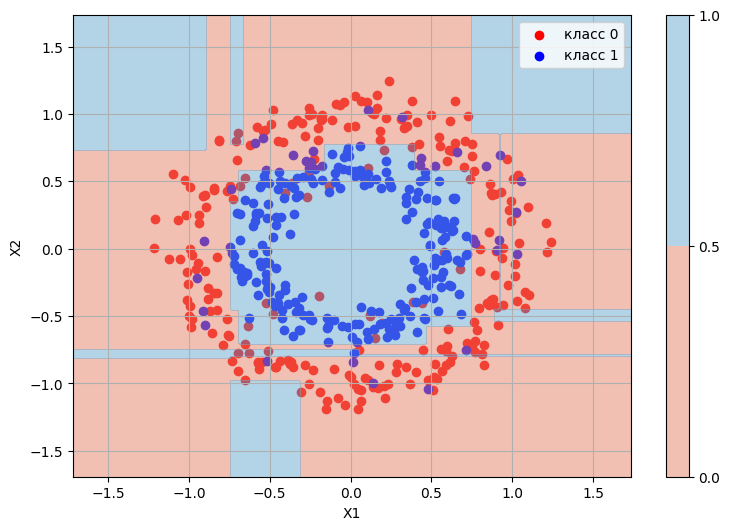

Максимальная глубина: 10
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       250
           1       0.87      0.84      0.85       250

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500



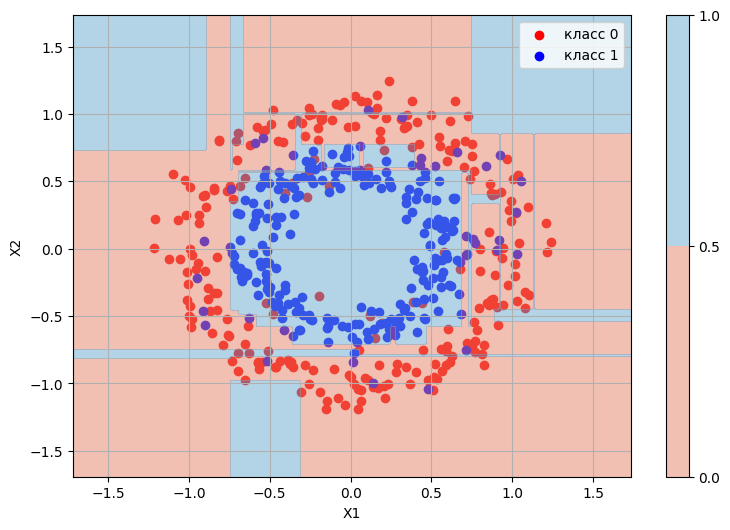

Максимальная глубина: 15
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       250
           1       0.85      0.83      0.84       250

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500



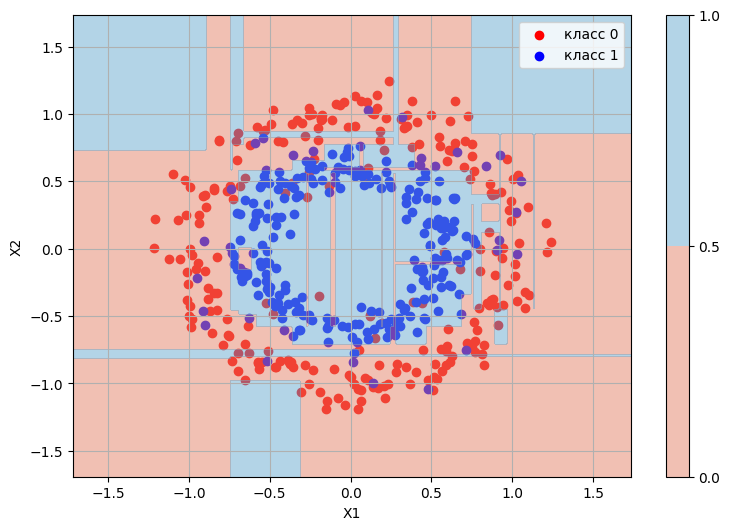

Максимальная глубина: 25
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       250
           1       0.85      0.82      0.84       250

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500



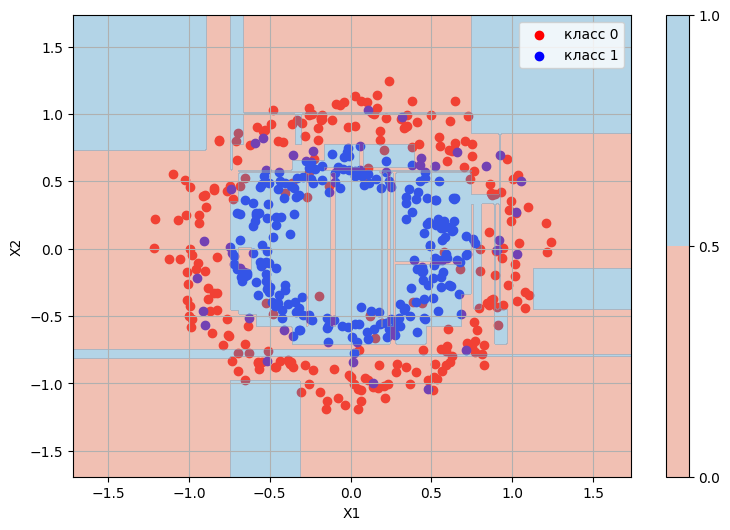

Максимальная глубина: 50
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       250
           1       0.85      0.82      0.84       250

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500



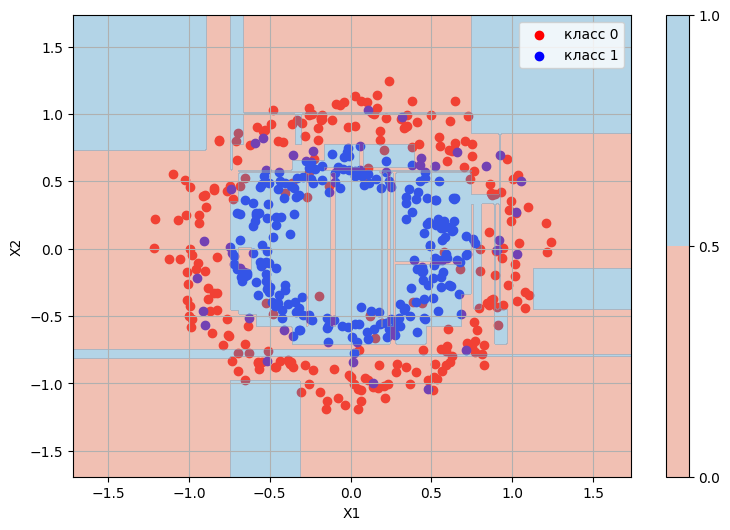

In [ ]:
%time
for depth in [1, 2, 4, 7, 10, 15, 25, 50]:
    print('Максимальная глубина:', depth)
    clf = DecisionTreeClassifier(max_depth=depth, criterion='gini', random_state=42)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    print(classification_report(y_test, pred))
    plot_decision_boundaries()

**Вопрос:** как `max_depth` связан с переобучением? Какое значение этого параметра выглядит оптимальным в данном примере?

**Минимальное число объектов в листе (`min_samples_leaf`)**

CPU times: total: 0 ns
Wall time: 0 ns
Минимальное число объектов в листе: 1
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       250
           1       0.85      0.82      0.84       250

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500



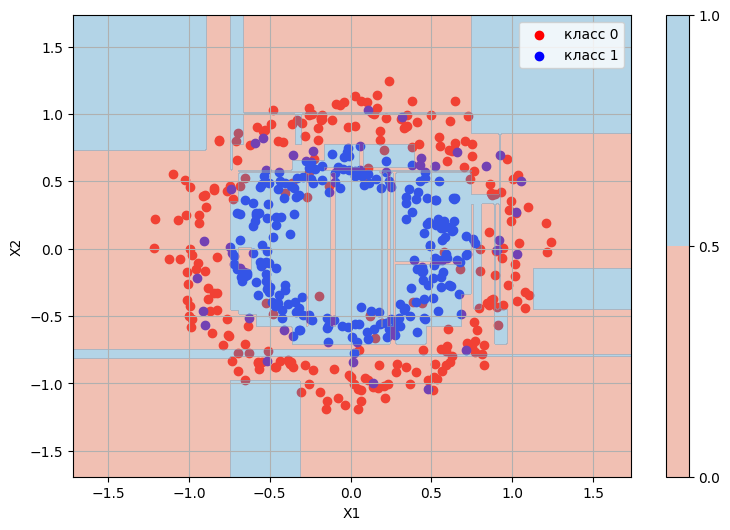

Минимальное число объектов в листе: 10
              precision    recall  f1-score   support

           0       0.82      0.91      0.87       250
           1       0.90      0.80      0.85       250

    accuracy                           0.86       500
   macro avg       0.86      0.86      0.86       500
weighted avg       0.86      0.86      0.86       500



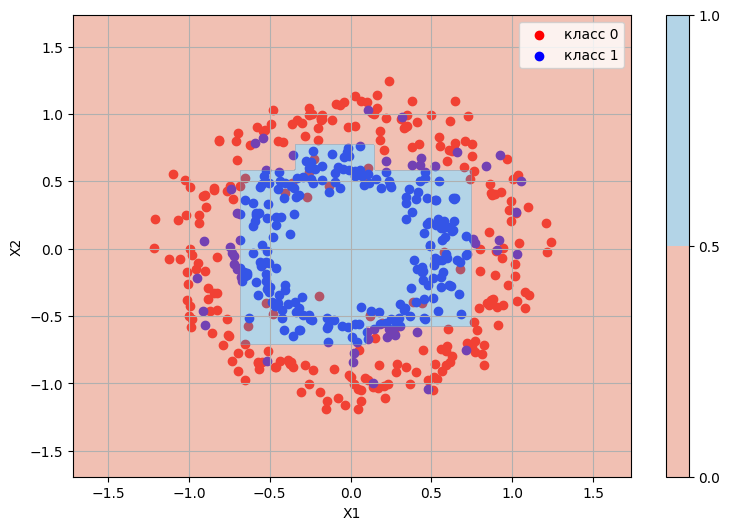

Минимальное число объектов в листе: 25
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       250
           1       0.89      0.81      0.85       250

    accuracy                           0.85       500
   macro avg       0.86      0.85      0.85       500
weighted avg       0.86      0.85      0.85       500



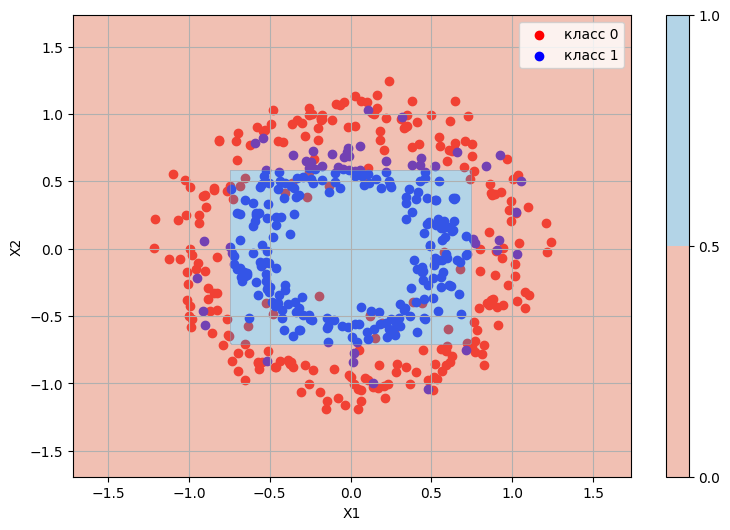

Минимальное число объектов в листе: 50
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       250
           1       0.89      0.81      0.85       250

    accuracy                           0.85       500
   macro avg       0.86      0.85      0.85       500
weighted avg       0.86      0.85      0.85       500



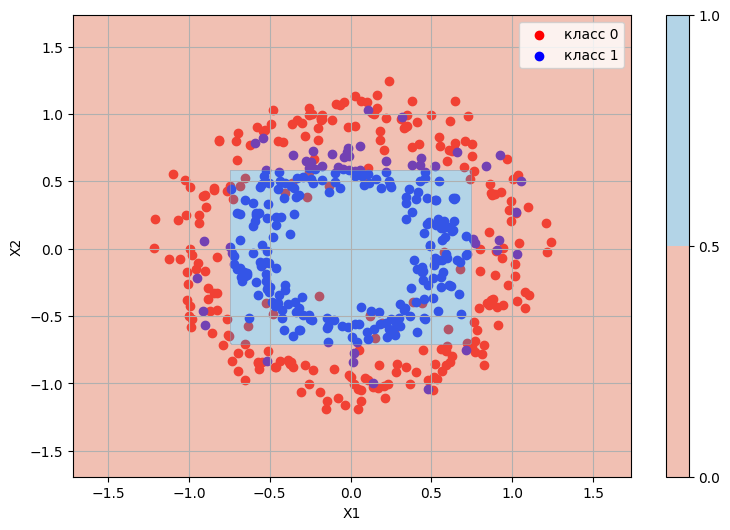

In [ ]:
%time
for sample in [1, 10, 25, 50]:
    print('Минимальное число объектов в листе:', sample)
    clf = DecisionTreeClassifier(min_samples_leaf=sample, criterion='gini', random_state=42)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    print(classification_report(y_test, pred))
    plot_decision_boundaries()

**Вопрос:** как `min_samples_leaf` связан с переобучением? Какое значение этого параметра выглядит оптимальным в данном примере?

**Задание:** исследуйте влияние остальных параметров дерева и сформулируйте выводы.

In [ ]:
# ВАШ КОД ЗДЕСЬ

# Решающее дерево для регрессии

Решающие деревья применяются и в задачах регрессии. Предсказанием в листе обычно служит среднее целевой переменной по обучающим объектам, попавшим в этот лист.

**Данные для задачи регрессии:** [California Housing](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html).

```
Признаки:
* MedInc — медианный доход в квартале;
* HouseAge — медианный возраст домов в квартале;
* AveRooms — среднее число комнат;
* AveBedrms — среднее число спален;
* Population — население квартала;
* AveOccup — среднее число жильцов в доме;
* Latitude — широта;
* Longitude — долгота.

Целевая переменная: медианная стоимость дома в сотнях тысяч долларов.
```

Файл `california_housing.csv` сохранён рядом с тетрадкой.

In [ ]:
from pathlib import Path

california_path = Path('california_housing.csv')
if not california_path.exists():
    raise FileNotFoundError('Положите файл california_housing.csv в одну папку с тетрадкой')

df = pd.read_csv(california_path)
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
X = df.drop('target', axis=1)
Y = df['target']
X_train, X_test, Y_train, Y_test =  train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((16512, 8), (4128, 8), (16512,), (4128,))

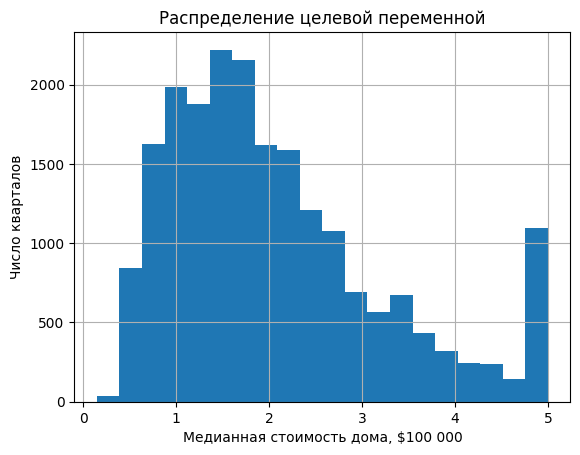

In [ ]:
import seaborn as sns

plt.hist(Y, bins=20)
plt.title('Распределение целевой переменной')
plt.xlabel('Медианная стоимость дома, $100 000')
plt.ylabel('Число кварталов')
plt.grid()
plt.show()

## Метрика

Для задачи регрессии используем корень из средней квадратичной ошибки (RMSE):

$$
RMSE = \sqrt{MSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(y_i - \hat y_i)^2}.
$$

In [ ]:
def rmse(y, y_hat):
    return np.sqrt(mean_squared_error(y_hat, y))

In [ ]:
from sklearn.tree import DecisionTreeRegressor

clf = DecisionTreeRegressor(random_state=0)
clf.fit(X_train, Y_train)
pred = clf.predict(X_test)
print('RMSE:', round(rmse(Y_test, pred), 3))

RMSE: 0.708


Неплохой результат, но попробуем его улучшить.

In [ ]:
from sklearn.model_selection import GridSearchCV

clf = DecisionTreeRegressor(random_state=42)
parameters = {
    'max_depth': [1, 3, 5, 7, 9],
    'min_samples_leaf': [1, 5, 10],
}

gs = GridSearchCV(
    clf,
    parameters,
    scoring='neg_mean_squared_error',
    cv=3,
)

gs.fit(X_train, Y_train)
gs.best_params_

{'max_depth': 9, 'min_samples_leaf': 10}

In [ ]:
pred = gs.predict(X_test)
print('RMSE:', round(rmse(Y_test, pred), 3))

RMSE: 0.627


После подбора параметров RMSE уменьшилась.

# Экстраполяция за пределы обучающей выборки

Важное ограничение дерева регрессии: оно практически не умеет экстраполировать за диапазон целевых значений обучающей выборки. Линейная регрессия, напротив, может продолжить найденную линейную зависимость.

**Вопрос:** почему дерево не может предсказать значение выше максимума или ниже минимума в обучающей выборке?

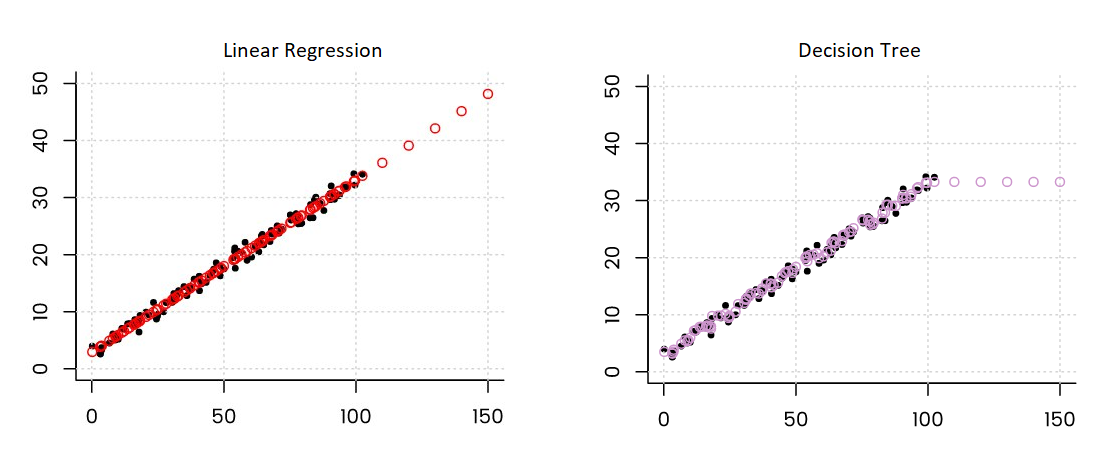

*Слева — линейная регрессия, которая продолжает зависимость; справа — решающее дерево, предсказание которого остаётся постоянным за пределами обучающего диапазона.*

Проверим это на данных. Искусственно поместим в тестовую выборку нижние и верхние 5% объектов по целевой переменной. Из оставшихся данных случайно добавим в тест ещё 10%.

In [ ]:
print('5-й процентиль:', round(df.target.quantile(0.05), 3))
print('95-й процентиль:', round(df.target.quantile(0.95), 3))

5-й процентиль: 0.662
95-й процентиль: 4.898


In [ ]:
# Нижние и верхние 5% значений помещаем в тест
df_test = df[(df.target < df.target.quantile(0.05)) |
             (df.target > df.target.quantile(0.95))]
df_train = df[(df.target > df.target.quantile(0.05)) &
              (df.target < df.target.quantile(0.95))]

# Случайно выбираем в тест ещё 10% оставшихся объектов
df_train, df_test_add = train_test_split(df_train, test_size=0.1, random_state=42)

# Объединяем две части тестовой выборки
df_test = pd.concat([df_test, df_test_add])
print('Доля обучающей выборки:', round(df_train.shape[0] / df.shape[0], 3))
print('Доля тестовой выборки:', round(df_test.shape[0] / df.shape[0], 3))

Доля обучающей выборки: 0.81
Доля тестовой выборки: 0.19


In [ ]:
df_test = df_test.sort_values('target')
X_train = df_train.drop('target', axis=1)
Y_train = df_train['target']
X_test = df_test.drop('target', axis=1)
Y_test = df_test['target']

In [ ]:
clf = DecisionTreeRegressor(random_state=42)
parameters = {
    'max_depth': [1, 3, 5, 7, 9],
    'min_samples_leaf': [1, 5, 10],
}

gs = GridSearchCV(
    clf,
    parameters,
    scoring='neg_mean_squared_error',
    cv=3,
)
gs.fit(X_train, Y_train)
pred = gs.predict(X_test)
print('RMSE:', round(rmse(Y_test, pred), 3))

RMSE: 0.887


In [ ]:
print('Минимум на обучении:', min(Y_train), '\tМаксимум на обучении:', max(Y_train))
print('Минимум прогноза:', round(min(pred), 3), '\tМаксимум прогноза:', round(max(pred), 3))
print('Минимум на тесте:', round(min(Y_test), 3), '\tМаксимум на тесте:', round(max(Y_test), 3))

Минимум на обучении: 0.663 	Максимум на обучении: 4.898
Минимум прогноза: 0.766 	Максимум прогноза: 4.644
Минимум на тесте: 0.15 	Максимум на тесте: 5.0


Все предсказания остаются внутри диапазона целевой переменной обучающей выборки. Дерево не экстраполирует на тестовые объекты, лежащие вне этого диапазона.

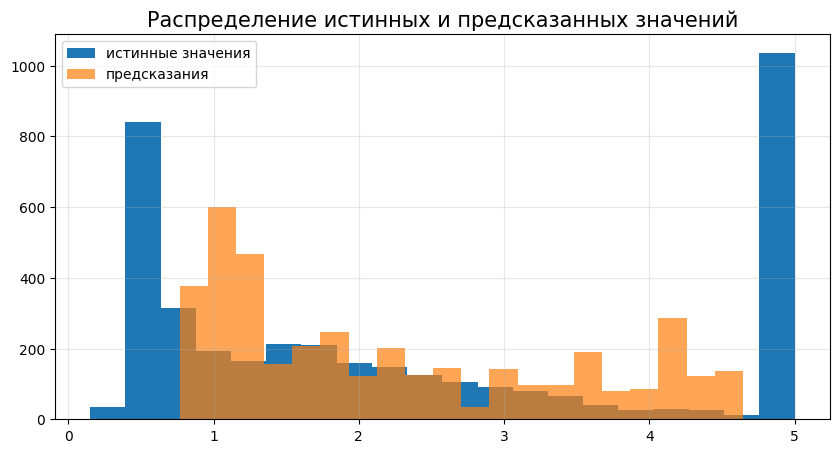

In [ ]:
plt.figure(figsize=(10, 5))
plt.grid(alpha=0.3)
plt.hist(Y_test, bins=20, label='истинные значения')
plt.hist(pred, alpha=0.7, bins=20, label='предсказания')
plt.title('Распределение истинных и предсказанных значений', size=15)
plt.legend()
plt.show()

Подробнее об экстраполяции можно прочитать в [этой статье](http://freerangestats.info/blog/2016/12/10/extrapolation).

## Обработка пропущенных значений

Поддержка пропусков зависит от конкретной модели и версии библиотеки. Универсальный подход — заполнить пропуски до обучения: простой статистикой (средним, медианой и т. п.) или отдельной моделью.

В качестве иллюстрации удалим 5% значений `HouseAge`, а затем восстановим их с помощью дополнительного решающего дерева, обученного на остальных признаках. В реальной задаче модель заполнения следует обучать только на обучающей части данных, иначе возможна утечка информации.

In [ ]:
good_index, missing_index = train_test_split(df.index, test_size=0.05, random_state=1)

# Искусственно удаляем 5% значений
df.loc[missing_index, 'HouseAge'] = np.nan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    19608 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
# Признаки, по которым будем восстанавливать пропуски
use_cols = [x for x in df.columns if x not in ['HouseAge', 'target']]
use_cols

['MedInc',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [ ]:
age_model = DecisionTreeRegressor(random_state=42)

# Обучаем дерево на строках с известным возрастом домов
age_model.fit(df.loc[good_index, use_cols], df.loc[good_index, 'HouseAge'])

# Предсказываем пропущенные значения
predicted_age = age_model.predict(df.loc[missing_index, use_cols])

# Заполняем пропуски без цепочечного присваивания
df.loc[missing_index, 'HouseAge'] = predicted_age
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
X = df.drop('target', axis=1)
Y = df['target']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

clf = DecisionTreeRegressor(random_state=42)
parameters = {
    'max_depth': [1, 3, 5, 7, 9],
    'min_samples_leaf': [1, 5, 10],
}

gs = GridSearchCV(
    clf,
    parameters,
    scoring='neg_mean_squared_error',
    cv=3,
)
gs.fit(X_train, Y_train)
pred = gs.predict(X_test)
print('RMSE:', round(rmse(Y_test, pred), 3))

(16512, 8) (4128, 8) (16512,) (4128,)


RMSE: 0.634


После восстановления пропусков получили $RMSE = 0{,}634$ против $0{,}627$ до искусственного удаления значений. Изменение невелико, но в этом запуске качество немного ухудшилось. Значит, сложное заполнение не гарантирует улучшения основной модели; способ импутации нужно сравнивать по кросс-валидации.

Подробнее об обработке пропусков можно прочитать в [этом обсуждении](https://stats.stackexchange.com/questions/98953/why-doesnt-random-forest-handle-missing-values-in-predictors?noredirect=1&lq=1).